# Анализ результатов эксперимента

## Контекст

У нас есть приложение с новостной лентой, где вместе с командой дата сайентистов мы провели несколько экспериментов.

Задача экспериментов - проверить эффективность новых алгоритмов рекомендаций в новостной ленте. Здесь приведены результаты анализа эксперимента для алгоритма, при котором показываем пользователю посты, наиболее похожие на те, **которые он лайкал**.

В качестве метрики эффективности был выбран CTR из просмотров в лайки.

**Почему мы взяли именно CTR?**

* Это довольно стандартная метрика;
* Есть явное действие, которое показывает заинтересованность – лайк.

Эксперименты проходили с 2025-11-21 по 2025-11-27 включительно. 

**Наши группы A/B-тестов**:

* 0, 1 - контрольная группа 

* 2 - тестовая группа для алгоритма "Показываем посты, похожие на лайкнутые"

Основная **гипотеза** заключается в том, что **новый алгоритм во 2-й группе приведет к увеличению CTR**.

## Настройка рабочей среды

Загрузим необходимые библиотеки:

In [5]:
import pandas as pd
import numpy as np
import pandahouse as ph
import swifter
import hashlib
import scipy as sp
from scipy import stats
from statsmodels.stats.weightstats import ztest
import seaborn as sns
import matplotlib.pyplot as plt

Настроим подключение к базе данных (с секретами):

In [ ]:
from dotenv import load_dotenv
import os
load_dotenv()

connection = {
    'host': os.getenv('CLICKHOUSE_HOST'),
    'database': os.getenv('CLICKHOUSE_DATABASE'),
    'user': os.getenv('CLICKHOUSE_USER'),
    'password': os.getenv('CLICKHOUSE_PASSWORD')
}


## АА-тест

Прежде чем проводить эксперимент, проанализируем наши данные и систему сплитования, чтобы убедиться, что данные разбиты по группам равномерно и корректно. Для этого проведём АА-тест.

Напишем запрос к БД, откуда вытащим данные по двум контрольным группам (0 и 1) за период с 14.11.2025 по 20.11.2025 включительно (неделя до планируемого эксперимента).

In [8]:
q_AA = """
SELECT 
    user_id,
    exp_group,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM {db}.feed_actions
WHERE toDate(time) between '2025-11-14' and '2025-11-20'
    and exp_group in (0, 1)
GROUP BY exp_group, user_id
""".format(db=connection['database'])

df_AA = ph.read_clickhouse(q_AA, connection=connection)
df_AA.groupby('exp_group').count().reset_index()

,exp_group,user_id,likes,views,ctr
0,0,8328,8328,8328,8328
1,1,8491,8491,8491,8491


В целом, видим, что разбивка по группам получилась равномерная: в обеих группах у нас примерно одинаковое количество наблюдений.

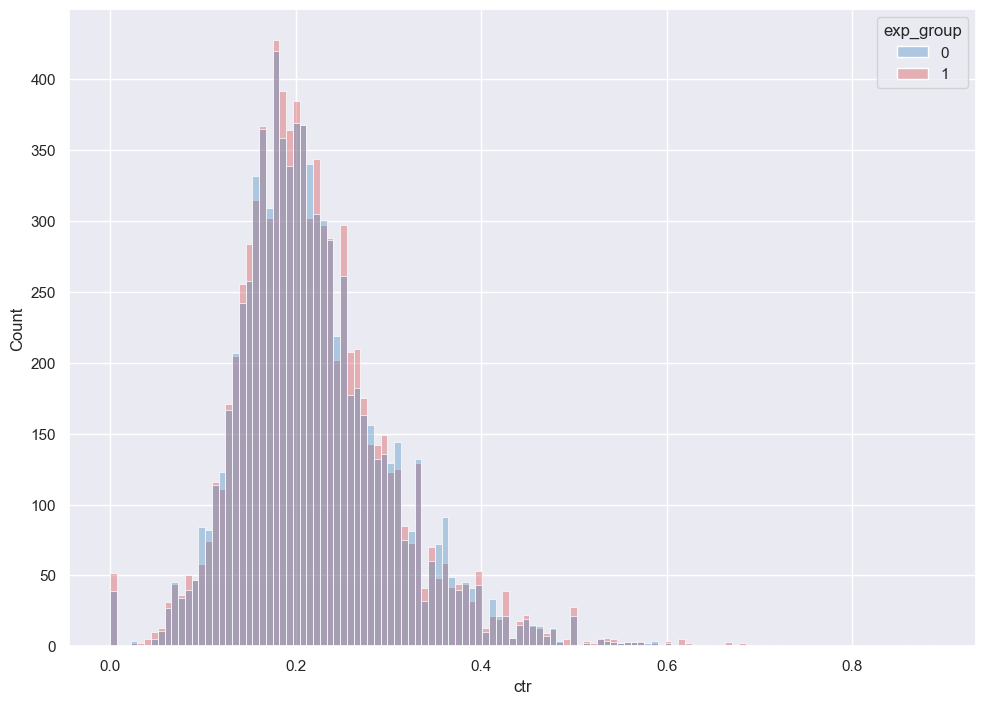

In [9]:
sns.set(rc = {'figure.figsize':(11.7,8.27)}) # здесь задаём масштабы графика, чтобы сделать его чуть крупнее

groups = sns.histplot(data = df_AA,
                      x = 'ctr',
                      hue = 'exp_group',
                      palette = ['tab:blue', 'tab:red'],
                      alpha = 0.3,
                      kde = False)

Судя по графику распределений CTR, наша основная метрика не отличается по группам до эксперимента. Убедимся в этом через статистический тест. Так как основная метрика выражена в пропорции и подчиняется биномаиальному распределению (0, 1), рассчитаем z-test о равенстве пропорций:

In [10]:
z_statistic, p_value = ztest(df_AA[df_AA.exp_group == 0].ctr, df_AA[df_AA.exp_group == 1].ctr, value = 0)

print(f"Z-statistic: {z_statistic:.4f}, p-value: {p_value:.4f}")

Z-statistic: -0.0703, p-value: 0.9440


Результаты теста показывают отсутствие значимой разницы в CTR между группами до проведения эксперимента. Дополнительно можем валидировать результаты и через t-test, предварительно проверив допущение о равенстве дисперсий между группами (тест Левина):

In [11]:
statistic, p_value = stats.levene(df_AA[df_AA.exp_group == 0].ctr, df_AA[df_AA.exp_group == 1].ctr)
print(f"Levene's test statistic: {statistic:.4f}")
print(f"P-value: {p_value:.4f}")

Levene's test statistic: 0.0696
P-value: 0.7919


Результаты теста показывают, что допущение о равенстве дисперсий не нарушено, поэтому посмотрим t-test с условием равных дисперсий.

In [42]:
ttest_result_AA = stats.ttest_ind(df_AA[df_AA.exp_group == 0].ctr,
                df_AA[df_AA.exp_group == 1].ctr,
                equal_var = True,
               alternative = 'two-sided')

print(f"(statistic={ttest_result_AA.statistic:.2f}, pvalue={ttest_result_AA.pvalue:.2e}, df={ttest_result_AA.df:.2f})")


(statistic=-0.07, pvalue=9.44e-01, df=16817.00)


Результаты т-теста получаются приблизительно аналогичными результатам z-test и показывают, что между группами **до** проведения эксперимента нет значимой разницы (p-value = 0.94). Дополнительно убедимся через тест Манна-Уитни: 

In [37]:
mann_result_AA = stats.mannwhitneyu(df_AA[df_AA.exp_group == 0].ctr,
                   df_AA[df_AA.exp_group == 1].ctr,
                   alternative = 'two-sided')

print(f"(statistic={mann_result_AA.statistic:.2f}, pvalue={mann_result_AA.pvalue:.2e})")

(statistic=35335824.00, pvalue=9.48e-01)


Тест Манна-Уитни также показывает отсутствие значимых отличий между распределениями наших контрольных групп. 

То есть, **до** эксперимента не было обнаружено ошибок в сплитовании или наблюдаемых различий между группами, не связанных с экспериментом. Поэтому можем проводить эксперимент и анализировать результаты.

## A/B тест

Теперь создаём запрос к БД, в котором вытаскиваем данные по группам 1 (контроль) и 2 (тест) за определённый период (даты проведения эксперимента):

In [14]:
q_AB = """
SELECT 
    user_id,
    exp_group,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM {db}.feed_actions
WHERE toDate(time) between '2025-11-21' and '2025-11-27'
    and exp_group in (1, 2)
GROUP BY exp_group, user_id
""".format(db=connection['database'])

Проверяем количество наблюдений по нашим группам:

In [15]:
df_AB = ph.read_clickhouse(q_AB, connection = connection)

df_AB.groupby('exp_group').count().reset_index()

,exp_group,user_id,likes,views,ctr
0,1,10020,10020,10020,10020
1,2,9877,9877,9877,9877


Количество наблюдений по группам приблизительно равное. Перейдём к анализу результатов эксперимента.

## Анализ результатов A/B теста

Теперь проанализируем наши результаты эксперимента.

Напомню:

exp_group = 1 - "Всё по старому" (контрольная группа)

exp_group = 2 - "Новый алгоритм рекомендаций: похожие на лайкнутые посты"

Посмотрим на распределение наших данных:

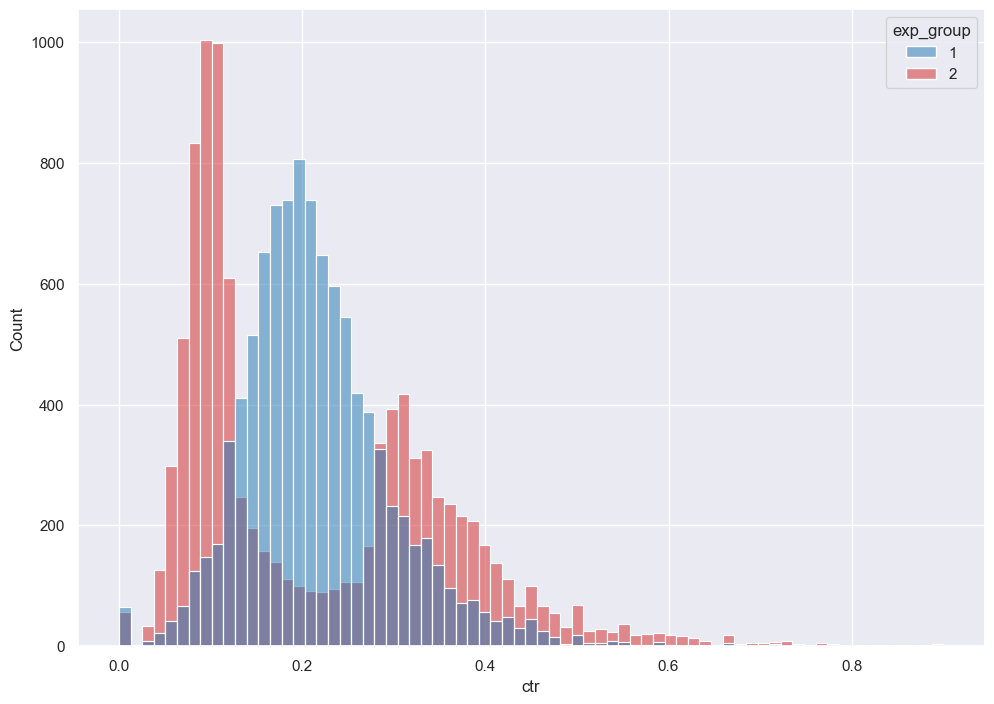

In [16]:
group_distr = sns.histplot(data = df_AB,
                      x = 'ctr',
                      hue = 'exp_group',
                      palette = ['tab:blue', 'tab:red'],
                      alpha = 0.5,
                      kde = False)

На графике видно, что CTR в тестовой группе (2) имеет бимодальное (двугорбое) распределение, в то время как CTR в контрольной группе приближен к нормальному.

То есть, среди пользователей тестовой группы есть как те, кто активно лайкал просмотренные посты, так и те, кто редко это делал. 

Что же могло быть причиной таких результатов?

1) возможно, на это повлияли технические сбои при проведении A/B-теста (из-за чего часть пользователей в тестовой группе не могли лайкать посты);

2) возможно, в нашей выборке для тестовой группы есть два сегмента юзеров, значимо отличающихся по важным для A/B-теста параметрам. 

3) возможно, есть внешний неучтённый фактор, который мог повлиять на сегменты пользователей внутри тестовой группы.

В любом случае использовать z-test или t-test с таким распределением - проблематично. Поэтому посмотрим для начала тест Манна-Уитни.

### Тест Манна-Уитни

In [36]:
mann_result_AB = stats.mannwhitneyu(df_AB[df_AB.exp_group == 1].ctr,
                   df_AB[df_AB.exp_group == 2].ctr,
                   alternative = 'two-sided')

print(f"(statistic={mann_result_AB.statistic:.2f}, pvalue={mann_result_AB.pvalue:.2e})")

(statistic=55189913.00, pvalue=4.63e-45)


**Интерпретация:** тест Манна-Уитни показывает значимую разницу в распределениях CTR между контрольной и тестовой группами (p-value = 0.000). Тем не менее, с учётом бимодальности распределения в тестовой группе, имеет смысл провести анализ с использованием дополнительных методов.

### T-test на сглаженном CTR

Может быть полезным посмотреть на сглаженный CTR вместо поюзерного, так как у нас могут быть пользователи с небольшим количеством просмотров, и тогда в их CTR много шума. То есть, чем меньше просмотров у пользователей, тем сложнее нам содержательно оценить их CTR, независимо от лайков (например, 3 лайка из 3 просмотров = 100% CTR, но этот CTR явно не равнозначен такому же CTR при 30 лайков/30 просмотров или, тем более, 300 лайков/300 просмотров).

Поэтому можно провести тесты на основе метрики сглаженного CTR (сглаживание Лапласа), рассчитанной по формуле: $$smoothedCTR_{u} =  {{likes_u + \alpha * globalCTR} \over {views_u + \alpha}} $$

In [18]:
# создаём функцию для рассчёта сглаженного CTR
def get_smoothed_ctr(user_likes, user_views, global_ctr, alpha):
    
    smoothed_ctr = (user_likes + alpha * global_ctr) / (user_views + alpha)
    
    return smoothed_ctr

In [19]:
# считаем общий CTR для контрольной группы    
global_ctr_1 = df_AB[df_AB.exp_group == 1].likes.sum()/df_AB[df_AB.exp_group == 1].views.sum()

# считаем общий CTR для тестовой группы
global_ctr_2 = df_AB[df_AB.exp_group == 2].likes.sum()/df_AB[df_AB.exp_group == 2].views.sum()


In [20]:
# создаём датафрейм для контрольной группы (где будет поюзерный CTR и сглаженный)

group1 = df_AB[df_AB.exp_group == 1].copy()

group1['smoothed_ctr'] = df_AB.apply(lambda x: get_smoothed_ctr(x['likes'], x['views'], global_ctr_1, 5), axis = 1)

In [21]:
# проверяем датафрейм

group1

,user_id,exp_group,likes,views,ctr,smoothed_ctr
0,109963,1,3,15,0.200000,0.202401
1,26117,1,32,141,0.226950,0.226356
2,138232,1,18,73,0.246575,0.244205
3,18392,1,7,32,0.218750,0.217514
4,26295,1,39,141,0.276596,0.274302
...,...,...,...,...,...,...
19886,31540,1,7,39,0.179487,0.182910
19887,23359,1,12,32,0.375000,0.352649
19890,110956,1,3,16,0.187500,0.192763
19891,132567,1,52,326,0.159509,0.160266


In [22]:
# создаём датафрейм с двумя видами CTR у тестовой группы

group2 = df_AB[df_AB.exp_group == 2].copy()

group2['smoothed_ctr'] = df_AB.apply(lambda x: get_smoothed_ctr(x['likes'], x['views'], global_ctr_2, 5), axis = 1)

In [23]:
group2

,user_id,exp_group,likes,views,ctr,smoothed_ctr
5,131473,2,9,108,0.083333,0.088507
6,23985,2,7,87,0.080460,0.086970
7,24523,2,11,101,0.108911,0.113219
8,32420,2,13,44,0.295455,0.285740
9,24239,2,40,90,0.444444,0.431592
...,...,...,...,...,...,...
19889,25071,2,7,18,0.388889,0.347881
19892,17146,2,0,10,0.000000,0.066750
19894,25383,2,42,127,0.330709,0.325767
19895,139020,2,17,41,0.414634,0.391332


Теперь посмотрим распределения сглаженного CTR в обеих группах:

Text(0.5, 1.0, 'Тестовая')

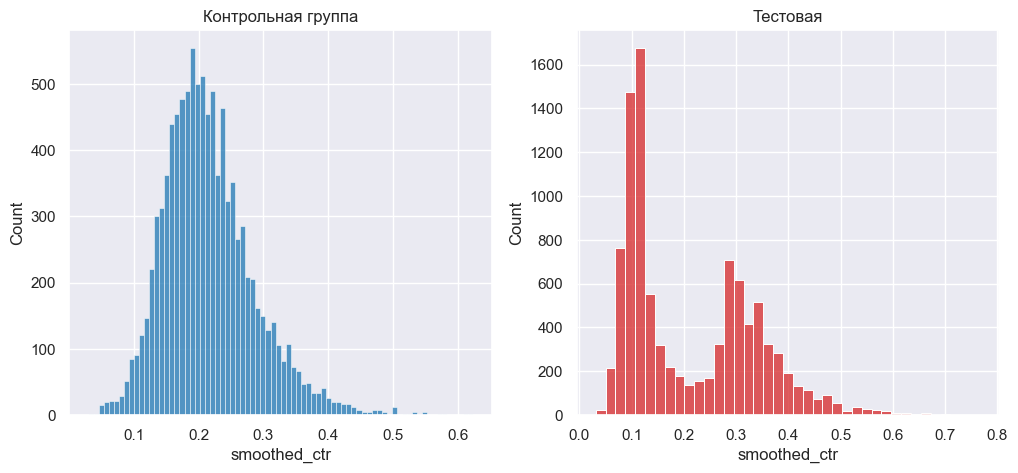

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(group1.smoothed_ctr, color = 'tab:blue', kde = False, ax=axes[0])
axes[0].set_title('Контрольная группа')
sns.histplot(group2.smoothed_ctr, color = 'tab:red', kde = False, ax=axes[1])
axes[1].set_title('Тестовая')



Опять же, бимодальное распределение не подходит для реализации параметрического теста, поэтому будем опираться на непараметрический тест Манна-Уитни:

In [43]:
mann_result_smooth = stats.mannwhitneyu(group1.smoothed_ctr,
                   group2.smoothed_ctr,
                   alternative = 'two-sided')

print(f"(statistic={mann_result_smooth.statistic:.2f}, pvalue={mann_result_smooth.pvalue:.2e})")

(statistic=55528353.00, pvalue=2.40e-50)


**Интерпретация:** результаты теста Манна-Уитни показывают значимые различия в рангах между тестовой и контрольной группами. То есть, на основе результатов этого теста мы также можем сказать, что CTR при новом алгоритме рекомендаций значимо отличается от CTR при старом. Причём, учитывая положительное значение статистики (55528353.0), CTR в контрольной группе выше, чем в тестовой.

### Пуассоновский бутстреп

Теперь сравним выборки через метод бутстрепа Пуассона. Для этого нам надо будет сначала посчитать лайки и просмотры внутри каждой из групп.

Далее, рассчитать глобальный CTR для каждой из групп A/B-теста по формулам:

для **контрольной** группы:
$$ globalCTR_A = {sum(likes_A * weights_1)\over sum(views_A * weights_1)}$$

для **тестовой** группы:
$$ globalCTR_B = {sum(likes_B * weights_2)\over sum(views_B * weights_2)}$$

Наконец, сравнить глобальные CTR, посмотрев на разницу в них.  

Создаём функцию для рассчёта глобального CTR для обеих групп:

In [44]:
def bootstrap(likes_control, views_control, likes_test, views_test, n_bootstrap):
    
    weights_control = stats.poisson(1).rvs((n_bootstrap, len(likes_control))).astype(np.int64)
    
    weights_test = stats.poisson(1).rvs((n_bootstrap, len(likes_test))).astype(np.int64)
    
    globalCTR_control = (likes_control * weights_control).sum(axis = 1) / (views_control * weights_control).sum(axis = 1)
    
    globalCTR_test = (likes_test * weights_test).sum(axis = 1)/(views_test * weights_test).sum(axis = 1)
    
    return globalCTR_control, globalCTR_test

Создаём списки значений количества лайков и просмотров для каждой из групп A/B теста:

In [45]:
likes_a = df_AB[df_AB.exp_group == 1].likes.to_numpy()
views_a = df_AB[df_AB.exp_group == 1].views.to_numpy()

likes_b = df_AB[df_AB.exp_group == 2].likes.to_numpy()
views_b = df_AB[df_AB.exp_group == 2].views.to_numpy()

Посчитаем CTR на 2000 симуляций:

In [46]:
ctr_a, ctr_b = bootstrap(likes_a, views_a, likes_b, views_b, n_bootstrap = 2000)

<Axes: ylabel='Count'>

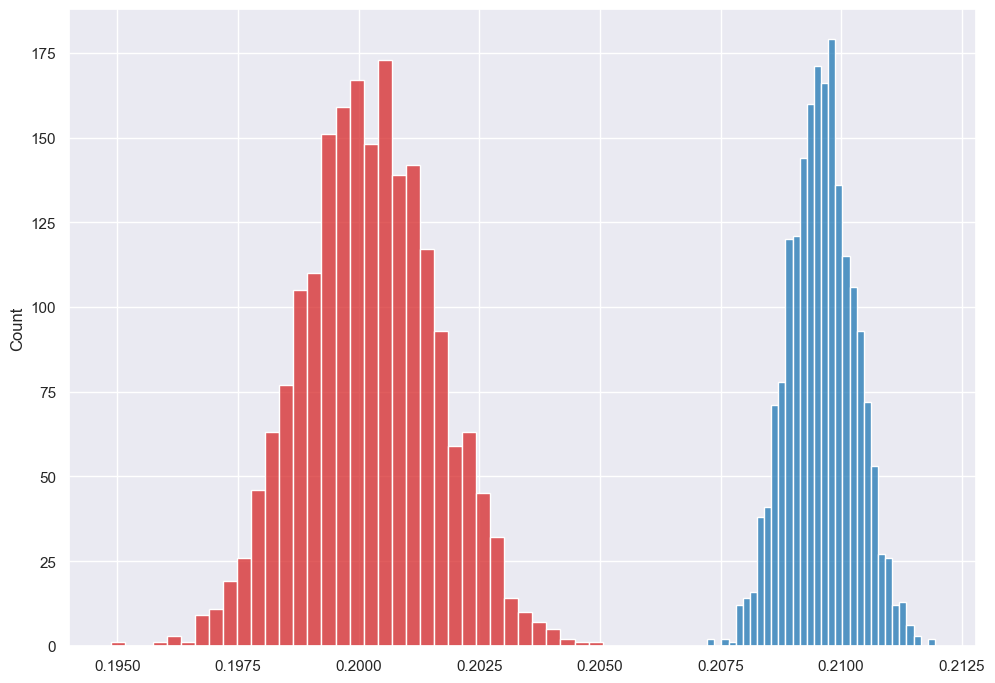

In [29]:
sns.histplot(ctr_a, color = 'tab:blue')
sns.histplot(ctr_b, color = 'tab:red')

<Axes: ylabel='Count'>

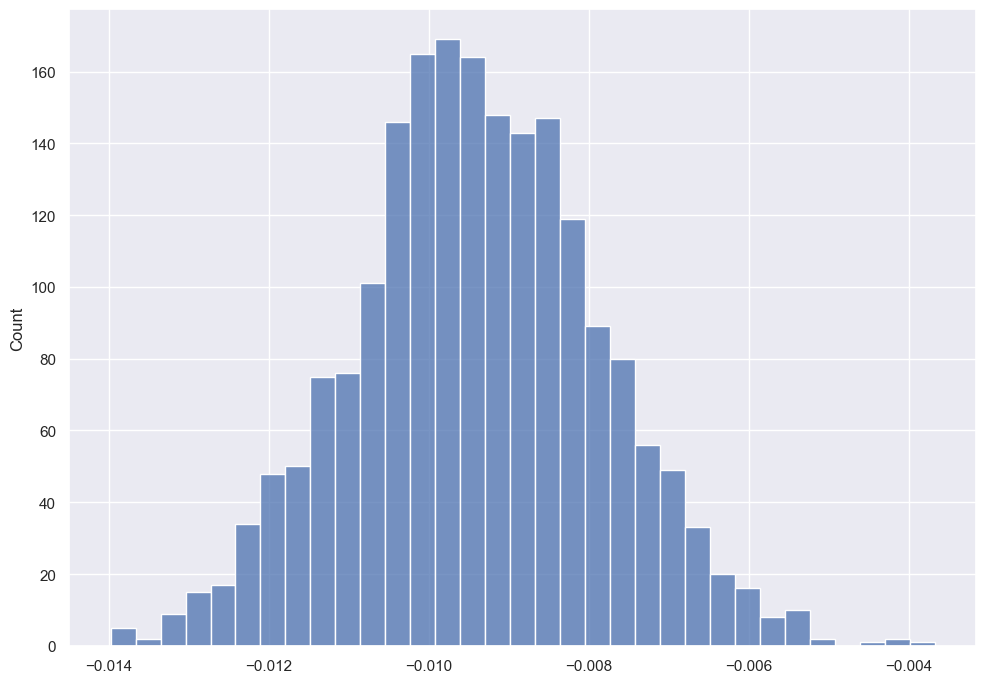

In [47]:
sns.histplot(ctr_b - ctr_a) # посмотрим также распределение разницы в CTR

В целом, по гистограмме распределений CTR и разницы в CTR между контрольной и тестовой группами мы видим, что есть значимая разница (графики распределения CTR по группам не пересекаются, и гистограмма распределения разницы не пересекает значение 0). При этом CTR в тестовой группе (ctr_b) ниже, чем CTR в контрольной (ctr_a), на что указывают и отрицательные значения распределения разницы между метриками. 

Также это можно увидеть на самих значениях средних по группам. Разница в среднем CTR в контрольной группе примерно на 1% выше, чем в тестовой:

In [48]:
print(f"{ctr_a.mean():.4f}, {ctr_b.mean():.4f}")

0.2096, 0.2002


Получается, наш новый алгоритм не просто значимо повлиял на CTR пользователей, но даже снизил его.

### Бакетное преобразование

Воспользуемся ещё одним методом анализа A/B тестов: бакетное преобразование. Для этого методом хэширования с солью разобьём наших пользователей на 50 бакетов (групп), посчитаем средний CTR для каждого из бакетов и сравним их уже для контрольной и тестовой групп.

In [49]:
q_backet = """
SELECT 
    exp_group, 
    bucket,
    sum(likes)/sum(views) as bucket_ctr
FROM (SELECT 
        exp_group,
        xxHash64(user_id)%50 as bucket,
        user_id,
        sum(action = 'like') as likes,
        sum(action = 'view') as views,
        likes/views as ctr
    FROM {db}.feed_actions
    WHERE toDate(time) between '2025-11-21' and '2025-11-27'
        and exp_group in (1, 2)
GROUP BY exp_group, bucket, user_id)
GROUP BY exp_group, bucket
""".format(db=connection['database'])

In [50]:
df_bucket = ph.read_clickhouse(q_backet, connection = connection)

<Axes: xlabel='bucket_ctr', ylabel='Count'>

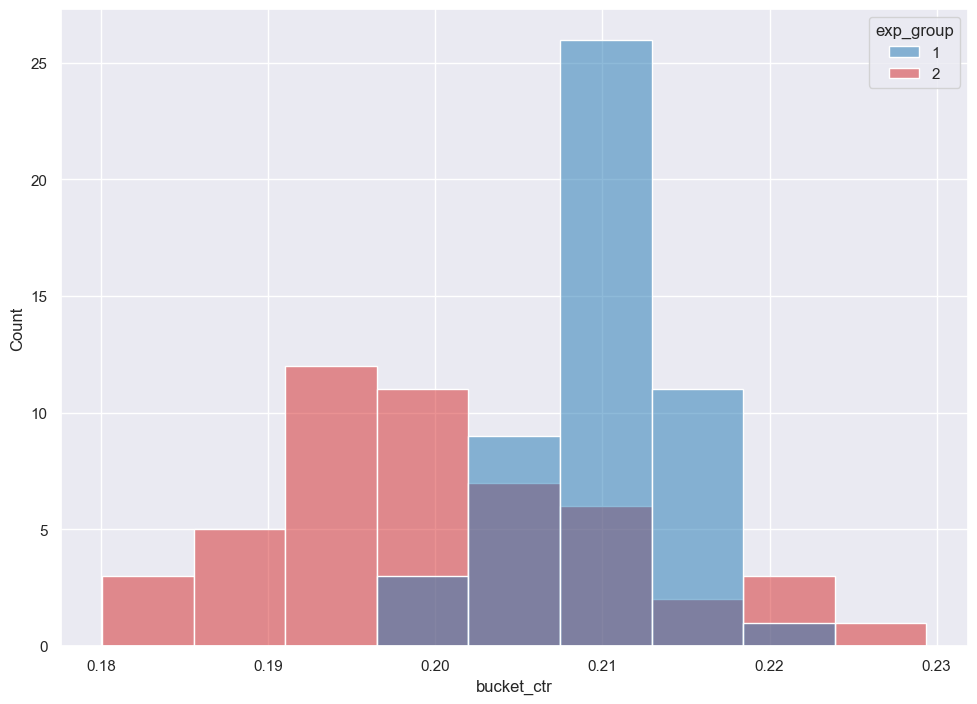

In [51]:
sns.histplot(data = df_bucket,
             x = 'bucket_ctr',
             hue = 'exp_group',
             palette = ['tab:blue', 'tab:red'],
             alpha=0.5,
             kde = False)

По распределениям тоже видим разницу между группами, причём в контрольной группе CTR оказывается выше, чем в тестовой, что мы видели и при бутстрэпе.

Такие распределения уже позволяют нам посчитать и t-test. Поэтому сравним результаты t-test и теста Манна-Уитни на бакетных выборках, предварительно проверив допущение о равенстве дисперсий:

In [52]:
statistic, p_value = stats.levene(df_bucket[df_bucket.exp_group == 1].bucket_ctr,
                df_bucket[df_bucket.exp_group == 2].bucket_ctr,)
print(f"Levene's test statistic: {statistic:.4f}")
print(f"P-value: {p_value:.4f}")

Levene's test statistic: 19.5178
P-value: 0.0000


Тест Ливина показывает, что дисперсии по группам значимо не равные, поэтому посчитаем t-test с поправкой Уэлча на неравенство дисперсий:

In [53]:
ttest_result_bucket = stats.ttest_ind(df_bucket[df_bucket.exp_group == 1].bucket_ctr,
                df_bucket[df_bucket.exp_group == 2].bucket_ctr,
                equal_var = False,
                alternative = 'two-sided')

print(f"(statistic={ttest_result_bucket.statistic:.2f}, pvalue={ttest_result_bucket.pvalue:.2e}, df={ttest_result_bucket.df:.2f})")


(statistic=5.61, pvalue=4.59e-07, df=63.83)


In [54]:
# тест Манна-Уитни
mann_result_bucket = stats.mannwhitneyu(df_bucket[df_bucket.exp_group == 1].bucket_ctr,
                   df_bucket[df_bucket.exp_group == 2].bucket_ctr,
                   alternative = 'two-sided')

print(f"(statistic={mann_result_bucket.statistic:.2f}, pvalue={mann_result_bucket.pvalue:.2e})")

(statistic=1997.00, pvalue=2.66e-07)


**Интерпретация:** оба теста показывают значимую разницу между группами (p < 0.01). То есть, по результатам теста с бакетным преобразованием мы можем сказать, что у группы пользователей с новым алгоритмом рекомендации постов, в среднем, CTR из просмотра в лайк значимо отличается от пользователей со старым алгоритмом рекомендаций.

Посмотрим саму разницу в средних:

In [58]:
mean_bucket_ctr_control = df_bucket[df_bucket.exp_group == 1].bucket_ctr.mean()
mean_bucket_ctr_test = df_bucket[df_bucket.exp_group == 2].bucket_ctr.mean()

print(f"Разница в CTR (тест - контроль): {mean_bucket_ctr_test - mean_bucket_ctr_control:.4f}")

Разница в CTR (тест - контроль): -0.0092


Тут тоже получается, что в среднем CTR тестовой группы ниже, чем CTR в контрольной группе, примерно на 1%.

### Рекомендации по итогам анализа

По результатам анализа можно сказать, что лучше **не раскатывать** новый алгоритм на всех пользователей.

Во-первых, исходное распределение целевой метрики в тестовой группе указывает на наличие какого-то существенного неучтённого параметра, повлиявшего на исход A/B теста. Возможно, имело бы смысл дополнительно провести сегментацию данных, чтобы понять, есть ли неучтённая вариация (и какая), повлиявшая на результаты.

Во-вторых, даже без учёта бимодальности в данных, результаты тестов, рассчитанных на скорректированных распределениях при помощи бутстрэпа и бакетизации, указывают на отрицательный эффект нового алгоритма: **в тестовой группе CTR значимо ниже**, чем в контрольной.